In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import warnings 
warnings.filterwarnings('ignore')
import keras
from tensorflow.keras.utils import to_categorical 
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout     

In [63]:
trainDF =  pd.read_csv('train.csv')


X = trainDF.drop(['label'], axis=1)
y = trainDF['label']

X = X/255.0

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

X_train_arr = X_train.values
X_test_arr = X_test.values

X_train_cnn = X_train_arr.reshape(-1, 28, 28, 1) 
X_test_cnn = X_test_arr.reshape(-1, 28, 28, 1) 

In [ ]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [66]:
trainDF
print(y_train_cat.shape)
print(y_test_cat.shape)

(33600, 10)
(8400, 10)


In [67]:
trainDF.shape

(42000, 785)

In [68]:
trainDF.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

### First trying it with perceptron

In [69]:
perceptron_model = Perceptron()
perceptron_model.fit(X_train, y_train)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


In [70]:
y_pred = perceptron_model.predict(X_test)
acc = accuracy_score(y_pred, y_test)

In [71]:
print(acc)

0.8796428571428572


### Trying it with ANN

In [72]:
ANN_model = keras.Sequential([
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

ANN_model.compile(optimizer='adam',loss="categorical_crossentropy", metrics=["accuracy"])

In [73]:
y_test.shape

(8400,)

In [74]:

history_ann = ANN_model.fit(X_train, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test, y_test_cat), verbose=1)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9104 - loss: 0.3030 - val_accuracy: 0.9501 - val_loss: 0.1646
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9623 - loss: 0.1241 - val_accuracy: 0.9615 - val_loss: 0.1241
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9739 - loss: 0.0845 - val_accuracy: 0.9670 - val_loss: 0.1032
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9804 - loss: 0.0625 - val_accuracy: 0.9670 - val_loss: 0.1050
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9849 - loss: 0.0465 - val_accuracy: 0.9646 - val_loss: 0.1180


In [80]:
acc_ann = ANN_model.evaluate(X_test, y_test_cat, verbose=2)[1]
print(acc_ann)

263/263 - 0s - 1ms/step - accuracy: 0.9646 - loss: 0.1180
0.9646428823471069


In [96]:
model_CNN = keras.Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape = (28, 28, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model_CNN.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_history = model_CNN.fit(X_train_cnn, y_train_cat, verbose=1, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_test_cat))

c:\Users\HP\OneDrive\Desktop\ML-DS\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9140 - loss: 0.2832 - val_accuracy: 0.9776 - val_loss: 0.0761
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9717 - loss: 0.0960 - val_accuracy: 0.9855 - val_loss: 0.0455
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9794 - loss: 0.0695 - val_accuracy: 0.9863 - val_loss: 0.0423
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9827 - loss: 0.0569 - val_accuracy: 0.9873 - val_loss: 0.0401
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9860 - loss: 0.0467 - val_accuracy: 0.9895 - val_loss: 0.0358


In [102]:
acc = model_CNN.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]
print(acc)

0.9895238280296326


In [110]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {np.argmax(y_true[idx])}")
        
        preds = []
        for model, name in zip(models, model_names):
            if name == "CNN":
                pred = np.argmax(model.predict(X_cnn[idx:idx+1], verbose=0))
            elif name == "Perceptron":
                pred = model.predict(X[idx:idx+1].reshape(1, -1))[0]
            else:  # ANN
                pred = np.argmax(model.predict(X[idx:idx+1], verbose=0))
            preds.append(pred)
        
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

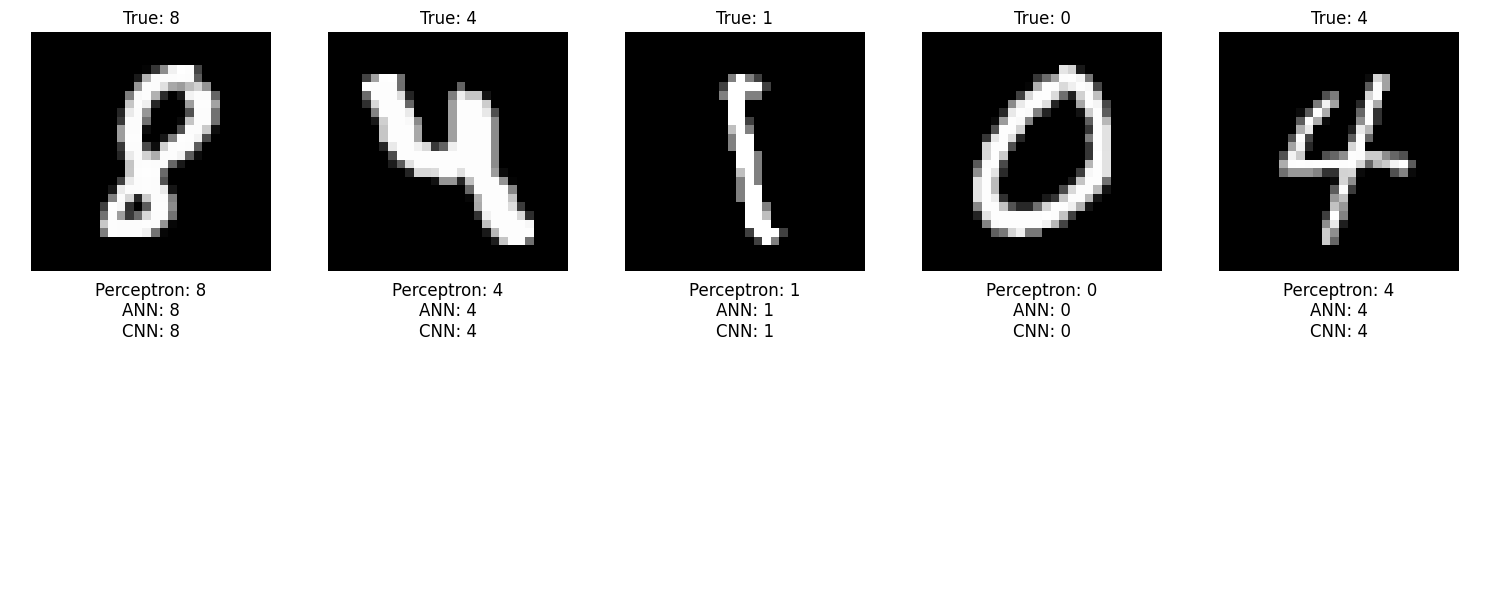

In [129]:
show_side_by_side([perceptron_model, ANN_model, model_CNN], ["Perceptron", "ANN", "CNN"], X_test_arr, X_test_cnn, y_test_cat, 5)